Progress: 100.0% completed

Melhor alocação encontrada (valores na escala do X de entrada):
   Legislative  Judiciary  Essential to Justice  Administration  \
0     0.238335  -0.315231             -0.106782        0.238499   

   National Defence  Public Safety  Foreign Relations  Social Assistance  \
0           0.05618       0.068128           -0.24225          -0.292825   

   Social Security    Health  ...  Agriculture  Agrarian Organisation  \
0        -0.604484 -0.638995  ...     0.329546              -0.800804   

   Industry  Services and Commerce  Communications    Energy  Transportation  \
0 -0.465135              -0.091238       -0.295434 -0.495962       -0.338299   

   Sports and Leisure  Special Charges  Refinancing  
0           -0.684491        -0.395147    -0.521554  

[1 rows x 29 columns]

Melhor alocação (rótulos para apresentação):
   Legislative  Judiciary  Essential to Justice  Administration  \
0     0.238335  -0.315231             -0.106782        0.238499   



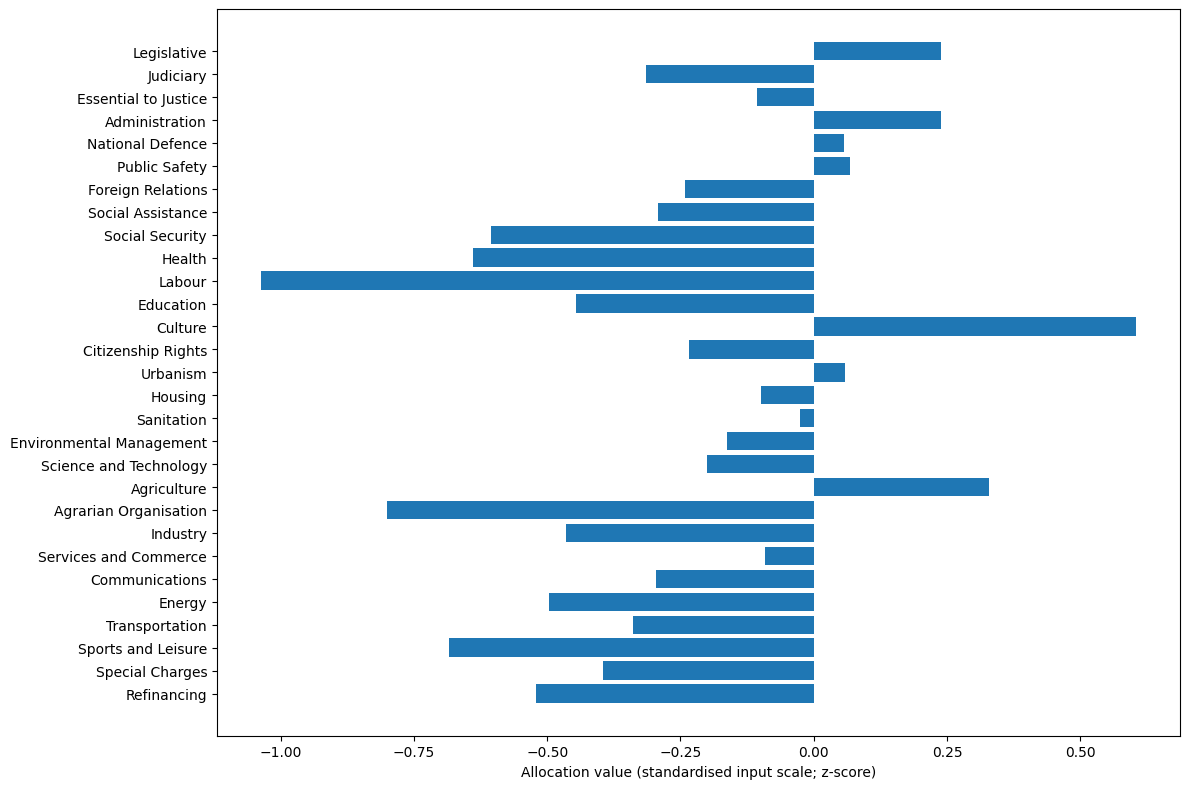


Arquivo salvo: best_allocation.csv
Gráfico salvo: graphs/optimized_allocation.png


In [1]:
# ================================================================
# SCRIPT 2 (Jupyter): Optimization (Optuna) consistent with Script 1
# - Loads MultiOutputRegressor model saved by Script 1 (saved_model.pkl)
# - Defines baseline/bounds from REAL data (Processed_Normalized_Data.csv)
#   to reduce synthetic-driven search space (anti-"math game" critique)
# - Objective supports weights (w_gdp, w_infl, w_gini) and penalties
# - Avoids Optuna import error by auto-install attempt
# Outputs:
#   best_allocation.csv
#   graphs/optimized_allocation.png
# ================================================================

from __future__ import annotations

import os
import sys
import math
import random
import subprocess
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib


# -----------------------------
# (0) Ensure Optuna (avoid ModuleNotFoundError)
# -----------------------------
def ensure_optuna(min_version: Optional[str] = None):
    """
    Tries to import optuna; if missing, attempts to install it using pip.
    This avoids ModuleNotFoundError in fresh environments.
    """
    try:
        import optuna  # noqa: F401
        return
    except ModuleNotFoundError:
        print("Optuna não está instalado. Tentando instalar via pip...")
        cmd = [sys.executable, "-m", "pip", "install", "optuna"]
        if min_version:
            cmd = [sys.executable, "-m", "pip", "install", f"optuna>={min_version}"]
        try:
            subprocess.check_call(cmd)
            import optuna  # noqa: F401
            print("Optuna instalado com sucesso.")
        except Exception as e:
            raise RuntimeError(
                "Falha ao instalar Optuna automaticamente.\n"
                "Instale manualmente no seu ambiente e reinicie o kernel:\n"
                "  pip install optuna\n"
            ) from e


ensure_optuna()
import optuna  # noqa: E402


# -----------------------------
# (1) Reprodutibilidade e pastas
# -----------------------------
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

Path("graphs").mkdir(parents=True, exist_ok=True)
optuna.logging.set_verbosity(optuna.logging.WARNING)


# -----------------------------
# (1.1) Display labels (Figura 7): alinhamento terminológico + inglês britânico
# - Mantém os nomes originais nas colunas (para não quebrar o modelo).
# - Ajusta apenas a apresentação (plot/prints).
# -----------------------------
DISPLAY_LABELS: Dict[str, str] = {
    # Ambiguidade: “Security” deve ser lido como Seguridade Social aqui
    "Security": "Social Security",
    "Security (Social Security)": "Social Security",
    "Social Security": "Social Security",

    # Coerência com inglês britânico (apresentação)
    "Labor": "Labour",
    "National Defense": "National Defence",
    "Agrarian Organization": "Agrarian Organisation",

    # Mantém “Public Safety” para Segurança Pública (se existir no CSV)
    "Public Safety": "Public Safety",
}


def display_name(col: str) -> str:
    return DISPLAY_LABELS.get(col, col)


# -----------------------------
# (2) Configuração
# -----------------------------
@dataclass(frozen=True)
class Config:
    # Inputs / artifacts
    model_path: str = "saved_model.pkl"
    real_data_csv: str = "Processed_Normalized_Data.csv"   # 24 obs (real)
    augmented_csv: str = "augmented_dataset.csv"          # for reference only
    out_best_csv: str = "best_allocation.csv"
    out_plot: str = "graphs/optimized_allocation.png"

    # Bounds strategy
    # Prefer quantile bounds to reduce extrapolation and tail artifacts.
    q_low: float = 0.05
    q_high: float = 0.95

    # Objective weights (paper baseline = equal weights on standardised scales)
    w_gdp: float = 1.0
    w_infl: float = 1.0
    w_gini: float = 1.0

    # Penalty on deviation from baseline (L1)
    lambda_reg: float = 0.5

    # Optional sum-neutrality penalty (OFF by default).
    # Use only if your X truly represents shares/parts of a fixed total.
    use_sum_penalty: bool = False
    lambda_sum: float = 0.0

    # Optimisation
    n_trials: int = 1000


CFG = Config()


# -----------------------------
# (3) Carregamento: modelo e dados reais
# -----------------------------
def load_model(path: str) -> object:
    if not Path(path).exists():
        raise FileNotFoundError(
            f"Não encontrei o modelo em '{path}'. "
            "Execute o Script 1 para gerar 'saved_model.pkl'."
        )
    model = joblib.load(path)
    return model


def load_real_X(path: str) -> pd.DataFrame:
    """
    Loads REAL data and returns X (same column convention as Script 1):
      - first column is an index/year
      - last 3 columns are targets
      - X = df.iloc[:, 1:-3]
    """
    if not Path(path).exists():
        raise FileNotFoundError(
            f"Não encontrei '{path}'. Coloque o CSV no mesmo diretório do notebook."
        )
    df = pd.read_csv(path)
    if df.shape[1] < 5:
        raise ValueError("CSV com poucas colunas. Verifique se é o arquivo correto.")

    X_real = df.iloc[:, 1:-3].copy()
    if X_real.shape[0] < 10:
        print("Aviso: poucas observações reais. Verifique o CSV.")
    return X_real


# -----------------------------
# (4) Baseline e Bounds (a partir do REAL)
# -----------------------------
def define_baseline_and_bounds_real(
    X_real: pd.DataFrame,
    q_low: float,
    q_high: float
) -> Tuple[Dict[str, float], Dict[str, Tuple[float, float]]]:
    """
    Baseline: median of REAL X (robust).
    Bounds: [q_low, q_high] quantiles on REAL X, clipped to [min, max] real.
    """
    baseline = X_real.median()
    bounds: Dict[str, Tuple[float, float]] = {}

    ql = X_real.quantile(q_low)
    qh = X_real.quantile(q_high)
    xmin = X_real.min()
    xmax = X_real.max()

    for col in X_real.columns:
        lo = float(max(ql[col], xmin[col]))
        hi = float(min(qh[col], xmax[col]))
        # Safety: if constant or degenerate, widen a tiny bit
        if not np.isfinite(lo) or not np.isfinite(hi) or lo >= hi:
            m = float(baseline[col])
            lo, hi = m - 1e-6, m + 1e-6
        bounds[col] = (lo, hi)

    return baseline.to_dict(), bounds


# -----------------------------
# (5) Função objetivo (coerente com o paper)
# -----------------------------
def objective(
    trial: optuna.Trial,
    model,
    baseline: Dict[str, float],
    bounds: Dict[str, Tuple[float, float]],
    cfg: Config
) -> float:
    """
    Score = (w1*GDP) - (w2*Inflation) - (w3*Gini) - lambda_reg*L1_distance - optional_sum_penalty

    Notes:
    - If your variables are z-scores, the score is also in standardised units.
    - Penalty is computed in the same units as X (standardised), consistent with paper reporting.
    """
    suggested = {}
    for col, (lo, hi) in bounds.items():
        suggested[col] = trial.suggest_float(col, lo, hi)

    # L1 penalty around baseline (keeps solution near historically plausible region)
    l1 = 0.0
    for col, b in baseline.items():
        l1 += abs(suggested[col] - b)
    penalty_reg = cfg.lambda_reg * l1

    # Optional "sum neutrality" penalty (OFF by default)
    penalty_sum = 0.0
    if cfg.use_sum_penalty and cfg.lambda_sum > 0:
        sum_suggested = float(np.sum(list(suggested.values())))
        sum_baseline = float(np.sum(list(baseline.values())))
        penalty_sum = cfg.lambda_sum * abs(sum_suggested - sum_baseline)

    X_df = pd.DataFrame([suggested])

    # Predict: model from Script 1 is MultiOutputRegressor -> returns shape (1,3)
    y_pred = model.predict(X_df)
    if isinstance(y_pred, (list, tuple)):
        y_pred = np.array(y_pred)
    y_pred = np.asarray(y_pred)

    if y_pred.ndim == 1:
        # Defensive: if some estimator returns (3,) instead of (1,3)
        gdp, infl, gini = float(y_pred[0]), float(y_pred[1]), float(y_pred[2])
    else:
        gdp, infl, gini = float(y_pred[0, 0]), float(y_pred[0, 1]), float(y_pred[0, 2])

    score = (cfg.w_gdp * gdp) - (cfg.w_infl * infl) - (cfg.w_gini * gini) - penalty_reg - penalty_sum
    return float(score)


def progress_callback(n_trials: int):
    def cb(study: optuna.Study, trial: optuna.Trial):
        done = len(study.trials)
        pct = (done / n_trials) * 100.0
        print(f"Progress: {pct:.1f}% completed", end="\r")
    return cb


def optimise_allocation(
    model,
    baseline: Dict[str, float],
    bounds: Dict[str, Tuple[float, float]],
    cfg: Config
) -> optuna.Study:
    sampler = optuna.samplers.TPESampler(seed=SEED)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(
        lambda t: objective(t, model, baseline, bounds, cfg),
        n_trials=cfg.n_trials,
        callbacks=[progress_callback(cfg.n_trials)]
    )
    print()  # newline after progress
    return study


# -----------------------------
# (6) Saídas: best_allocation + gráfico
# -----------------------------
def plot_best_allocation(best_df: pd.DataFrame, out_path: str) -> None:
    plt.figure(figsize=(12, 8))

    # Apresentação: rótulos ajustados (Social Security, Labour, Defence, Organisation)
    labels = [display_name(c) for c in best_df.columns]
    values = best_df.iloc[0].values

    plt.barh(labels, values)
    plt.xlabel("Allocation value (standardised input scale; z-score)")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(out_path)
    plt.show()


# -----------------------------
# (7) Main
# -----------------------------
def main(cfg: Config) -> None:
    model = load_model(cfg.model_path)
    X_real = load_real_X(cfg.real_data_csv)

    baseline, bounds = define_baseline_and_bounds_real(
        X_real=X_real,
        q_low=cfg.q_low,
        q_high=cfg.q_high
    )

    study = optimise_allocation(model, baseline, bounds, cfg)
    best_params = study.best_trial.params
    best_df = pd.DataFrame([best_params])

    print("\nMelhor alocação encontrada (valores na escala do X de entrada):")
    print(best_df)
    best_df.to_csv(cfg.out_best_csv, index=False)

    # Print adicional (apresentação) com rótulos ajustados
    best_df_display = best_df.rename(columns=display_name)
    print("\nMelhor alocação (rótulos para apresentação):")
    print(best_df_display)

    y_best = model.predict(best_df)
    y_best = np.asarray(y_best)
    if y_best.ndim == 1:
        gdp, infl, gini = y_best[0], y_best[1], y_best[2]
    else:
        gdp, infl, gini = y_best[0, 0], y_best[0, 1], y_best[0, 2]

    print("\nResultados previstos com a melhor alocação (na escala do y do Script 1):")
    print(f"GDP growth: {float(gdp)}")
    print(f"Inflation:  {float(infl)}")
    print(f"Gini index: {float(gini)}")

    plot_best_allocation(best_df, cfg.out_plot)
    print(f"\nArquivo salvo: {cfg.out_best_csv}")
    print(f"Gráfico salvo: {cfg.out_plot}")


main(CFG)
